Dataset Preview:
    Experience  EducationLevel  ProjectHandled  WorkingHours  PerformanceScore  \
0           7               2               1            11                 2   
1           4               3               9             9                 1   
2          13               2              11             9                 4   
3          11               3              16            10                 3   
4           8               1               7             7                 2   

   Salary  Attrition  
0   26311          1  
1   51949          0  
2   45768          0  
3   60990          0  
4   36034          0  


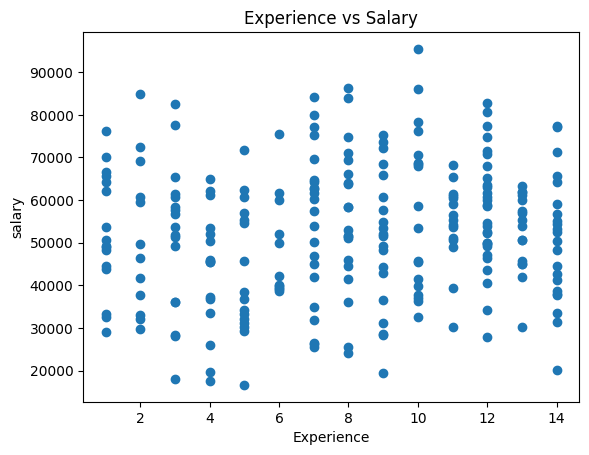

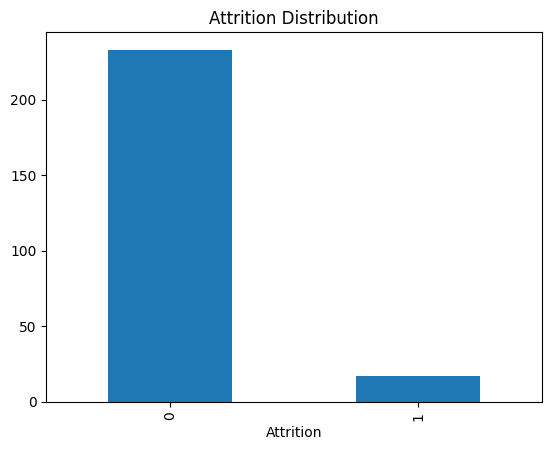

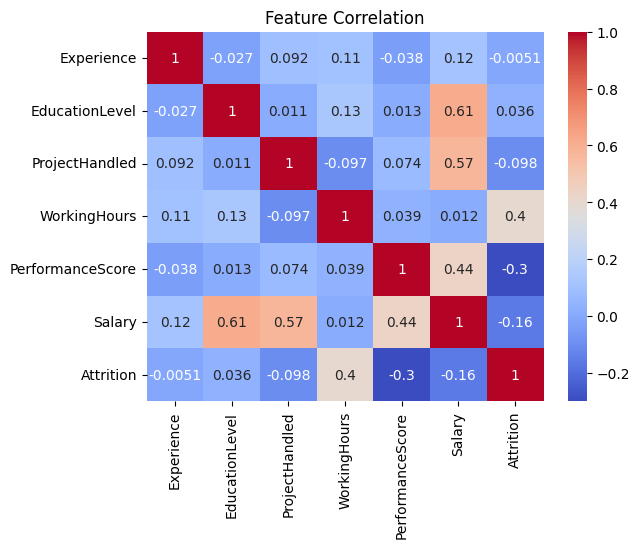

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(



Salary Prediction Reults
R2 Score: -76.3296236921254
RMSE: 141677.71792548842


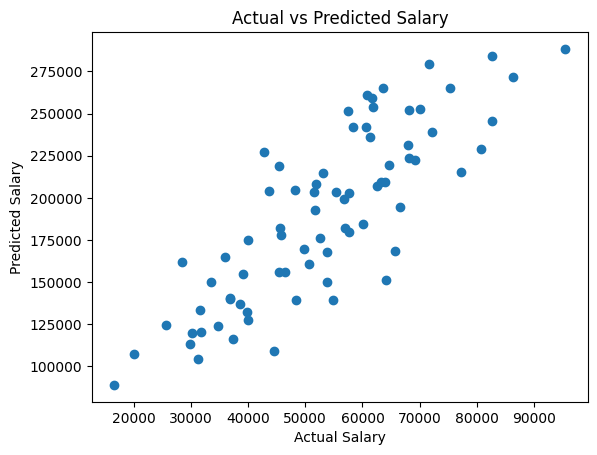


Attrition Predictio Results
Accuracy: 1.0
Confusion Matrix:
 [[68  0]
 [ 0  7]]
Cross Validation Accuracy: 1.0


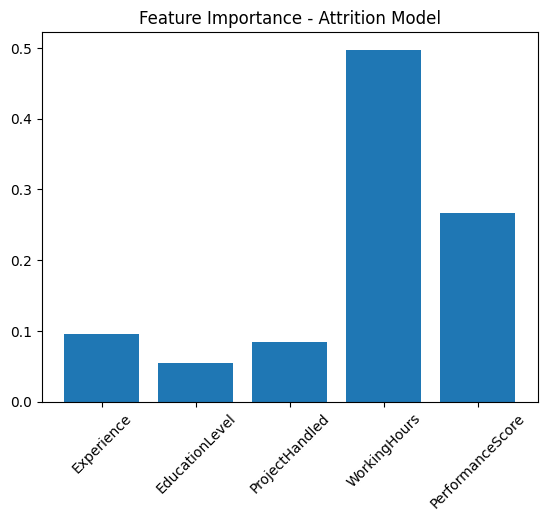


Project Completed Successfully!3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import accuracy_score,confusion_matrix

np.random.seed(42)

data=pd.DataFrame({
    "Experience":np.random.randint(1,15,250),
    "EducationLevel":np.random.randint(1,5,250),
    "ProjectHandled":np.random.randint(1,20,250),
    "WorkingHours":np.random.randint(6,12,250),
    "PerformanceScore":np.random.randint(1,6,250)
})

data["Salary"]=(
    data["Experience"]*500+
    data["EducationLevel"]*8000+
    data["ProjectHandled"]*1500+
    data["PerformanceScore"]*4000+
    np.random.randint(-10000,10000,250)
)

data["Attrition"]=np.where(
    (data["WorkingHours"]>10)&
    (data["PerformanceScore"]<3),1,0

)
print("Dataset Preview:\n",data.head())

plt.figure()
plt.scatter(data["Experience"],data["Salary"])
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("salary")
plt.show()
plt.figure()
data["Attrition"].value_counts().plot(kind='bar')
plt.title("Attrition Distribution")
plt.show()

plt.figure()
sns.heatmap(data.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

x_reg=data.drop(["Salary","Attrition"],axis=1)
y_reg=data["Salary"]

x_train_r,x_test_r,y_train_r,y_test_r=train_test_split(
    x_reg,y_reg,test_size=0.3,random_state=42
)
scaler=StandardScaler()
x_train_r =scaler.fit_transform(x_train_r)
reg_model=LinearRegression()
reg_model.fit(x_train_r,y_train_r)
y_pred_r=reg_model.predict(x_test_r)
print("\nSalary Prediction Reults")
print("R2 Score:",r2_score(y_test_r,y_pred_r))
print("RMSE:",np.sqrt(mean_squared_error(y_test_r,y_pred_r)))

plt.figure()
plt.scatter(y_test_r,y_pred_r)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

x_clf=data.drop(["Salary","Attrition"],axis=1)
y_clf=data["Attrition"]

x_train_c,x_test_c,y_train_c,y_test_c=train_test_split(
    x_clf,y_clf,test_size=0.3,random_state=42
)
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(x_train_c,y_train_c)

y_pred_c=rf_model.predict(x_test_c)

print("\nAttrition Predictio Results")
print("Accuracy:",accuracy_score(y_test_c,y_pred_c))
print("Confusion Matrix:\n",confusion_matrix(y_test_c,y_pred_c))

cv_score=cross_val_score(rf_model,x_clf,y_clf,cv=5)
print("Cross Validation Accuracy:",cv_score.mean())

importance=rf_model.feature_importances_
features=x_clf.columns

plt.figure()
plt.bar(features,importance)
plt.xticks(rotation=45)

plt.title("Feature Importance - Attrition Model")
plt.show()

print("\nProject Completed Successfully!3")